# MNIST

In [155]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, precision_recall_curve, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

mnist = fetch_openml("mnist_784", as_frame=False)


xRaw, yRaw = mnist.data, mnist.target
xRaw, yRaw

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object))

In [156]:
def displayImage(array):
    imageArray = array.reshape(28,28)
    plt.imshow(imageArray, cmap="binary")
    plt.axis("off")
    plt.show()


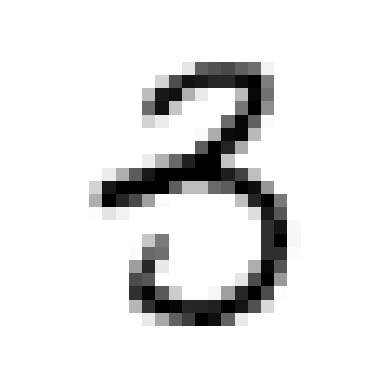

'3'

In [157]:
randomDigit = xRaw[254]
displayImage(randomDigit)
yRaw[254]

In [158]:
xTrain, xTest, yTrain, yTest = xRaw[:60000, :], xRaw[60000:, :], yRaw[:60000], yRaw[60000:]
xTrain, xTest, yTrain, yTest

(array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(60000, 784)),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(10000, 784)),
 array(['5', '0', '4', ..., '5', '6', '8'], shape=(60000,), dtype=object),
 array(['7', '2', '1', ..., '4', '5', '6'], shape=(10000,), dtype=object))

# Binary Classification

In [159]:
classifierModel = SGDClassifier(random_state=67)

In [160]:
yTr = (yTrain=='3')
yTe = (yTest=='3')
yTr, yTe

(array([False, False, False, ..., False, False, False], shape=(60000,)),
 array([False, False, False, ..., False, False, False], shape=(10000,)))

In [161]:
classifierModel.fit(xTrain, yTr)
classifierModel.predict([xTrain[74]])

array([ True])

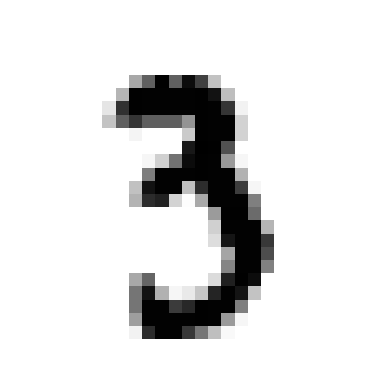

(np.True_, '3')

In [162]:
displayImage(xTrain[74])
yTr[74], yTrain[74]

In [163]:
testModel = SGDClassifier(random_state=67)
testModel.fit(xTrain, yTrain)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


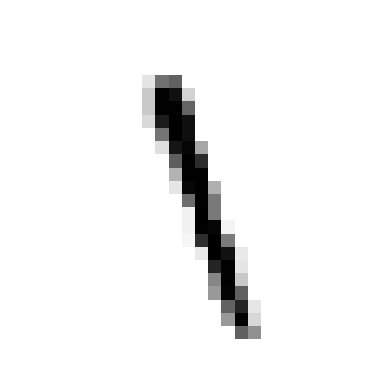

Index: 40052
AI says: 1	Fact: 1


In [164]:
randomIndex = np.random.randint(low=0, high=60000, dtype=int)
displayImage(xTrain[randomIndex])
print(f"Index: {randomIndex}")
print(f"AI says: {int(testModel.predict([xTrain[randomIndex]])[0])}\tFact: {yTrain[randomIndex]}")


# Custom cross_val_score()

In [165]:
def print_crose_val_accuracy(xTrain, yTr):
    kFolds = StratifiedKFold(n_splits=5)


    scores = np.array([])

    i = 0
    for trainIndex, testIndex in kFolds.split(xTrain, yTr):
        clonedModel = clone(classifierModel)
        trainX = xTrain[trainIndex,:]
        trainY = yTr[trainIndex]
        testX = xTrain[testIndex, :]
        testY = yTr[testIndex]
        clonedModel.fit(trainX, trainY)
        predictionSum = sum((clonedModel.predict(testX)==testY))
        acuracy = int(((predictionSum/(len(testY))).round(2))*100)
        scores = np.append(scores, acuracy)
        print(f"Score {i}: {acuracy}%")
        i = i+1
    print(f"Mean accuracy {int(scores.mean())}%")
    return scores

In [166]:
print_crose_val_accuracy(xTrain, yTr)

Score 0: 96%
Score 1: 97%
Score 2: 96%
Score 3: 95%
Score 4: 96%
Mean accuracy 96%


array([96., 97., 96., 95., 96.])

# Confussion Matrix

In [167]:
predictionsOfY = cross_val_predict(classifierModel, xTrain, yTr, cv=5, n_jobs=-1) #Now every predictions is done on unseen data
confusionMatrixResult = confusion_matrix(yTr, predictionsOfY)

In [168]:
confusionMatrixResult

array([[52848,  1021],
       [ 1325,  4806]])

In [169]:
print("""Here:
    This column represents predicted non 3   This column represents predicted 3
array([[52848,                                    1021] This row represents actual non 3,
       [ 1325,                                    4806]]) This row represents actual 3""")

Here:
    This column represents predicted non 3   This column represents predicted 3
array([[52848,                                    1021] This row represents actual non 3,
       [ 1325,                                    4806]]) This row represents actual 3


In [170]:
print("""A perfect result would look something like this:
array([[52848,  0],
       [ 0,  4806]])
""")

A perfect result would look something like this:
array([[52848,  0],
       [ 0,  4806]])



# Precission vs Recall || f1_score

In [171]:
print(f"Precission: {int(precision_score(yTr, predictionsOfY)*100)}%")

Precission: 82%


In [172]:
print(f"Recall: {int(recall_score(yTr, predictionsOfY)*100)}%")

Recall: 78%


In [173]:
print(f"F1: {int(f1_score(yTr, predictionsOfY)*100)}%")

F1: 80%


# Pricision Recall curve

In [174]:
decisionScoreOfY = cross_val_predict(classifierModel, xTrain, yTr, cv=5, method="decision_function", n_jobs=-1)
decisionScoreOfY

array([ -2962.08920106, -12408.92897118,  -3689.89885692, ...,
       -16224.31586526, -23535.72595406, -36949.07898232], shape=(60000,))

In [175]:
precision, recall, thresholds = precision_recall_curve(yTr, decisionScoreOfY)

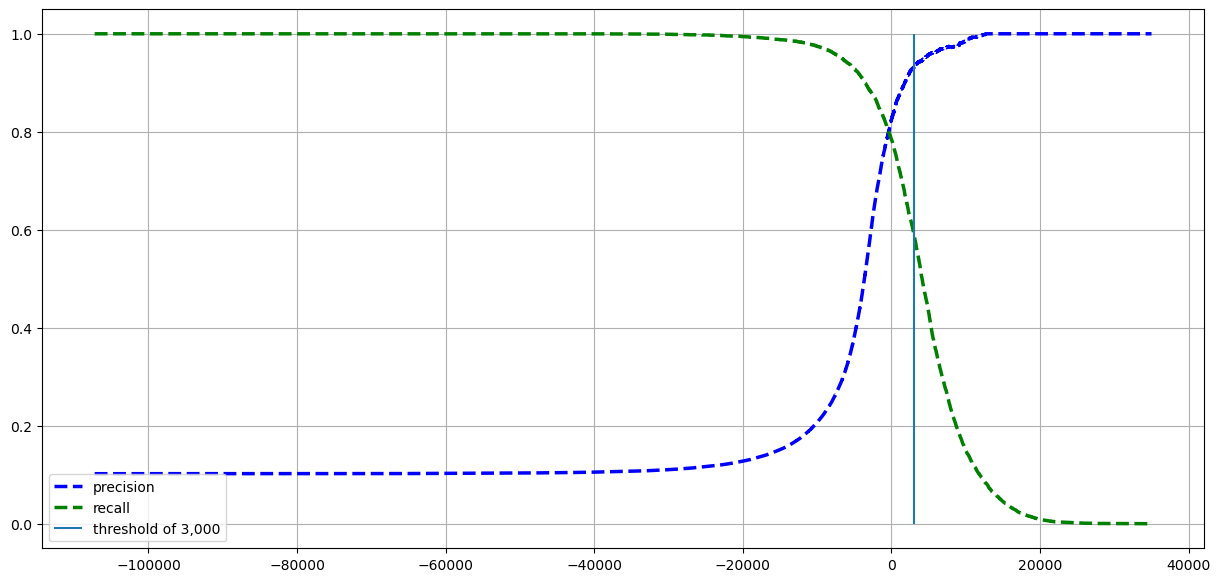

In [176]:
plt.figure(figsize=(15,7))
plt.plot(thresholds, precision[:-1], "b--", label="precision", linewidth=2.5)
plt.plot(thresholds, recall[:-1], "g--", label="recall", linewidth=2.5)
plt.vlines(3000, ymin=0, ymax=1, label="threshold of 3,000", linewidth=1.5)
plt.grid(True)
plt.legend()
plt.show()

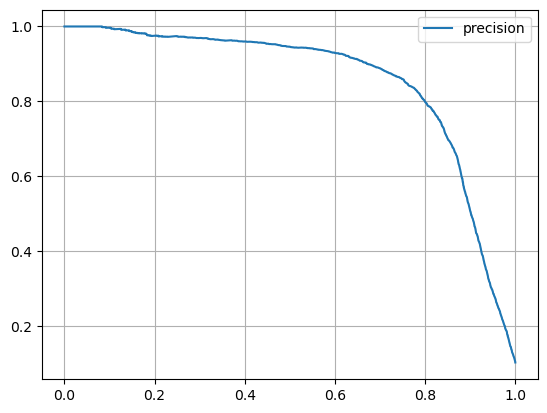

In [177]:
sns.lineplot(x=recall, y=precision, label="precision")
plt.grid(True)
plt.legend()
plt.show()

# Tune Threshold

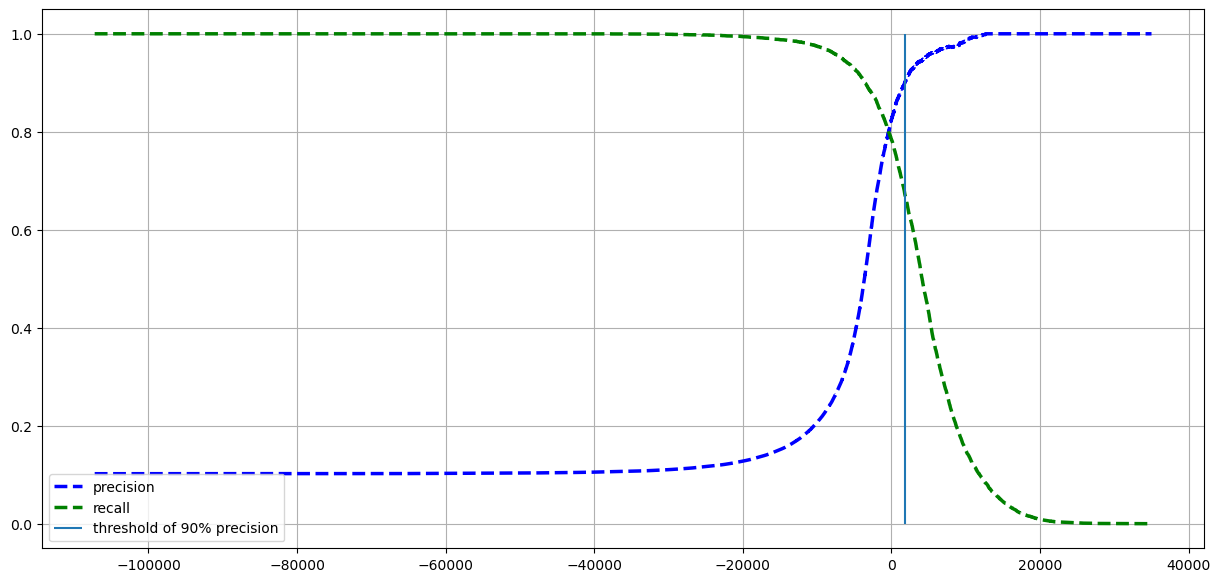

In [178]:
indexOf9Precision = (precision >= 0.9).argmax()
thresholdOf90Precision = thresholds[indexOf9Precision]
plt.figure(figsize=(15,7))
plt.plot(thresholds, precision[:-1], "b--", label="precision", linewidth=2.5)
plt.plot(thresholds, recall[:-1], "g--", label="recall", linewidth=2.5)
plt.vlines(thresholdOf90Precision, ymin=0, ymax=1, label="threshold of 90% precision", linewidth=1.5)
plt.grid(True)
plt.legend()
plt.show()

In [179]:
tunedPredictionY = (decisionScoreOfY >= thresholdOf90Precision)

In [180]:
print(f"Precission: {int(precision_score(yTr, tunedPredictionY)*100)}%")

Precission: 90%


In [181]:
print(f"Recall: {int(recall_score(yTr, tunedPredictionY)*100)}%") # Got down as usual!

Recall: 67%


In [182]:
print(f"F1: {int(f1_score(yTr, tunedPredictionY)*100)}%") # Not bad!

F1: 77%


In [183]:
print(f"Accuracy: {int(accuracy_score(yTr, tunedPredictionY)*100)}%") # Not bad!

Accuracy: 95%


# Little test

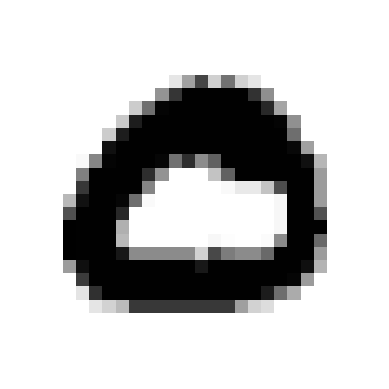

Is this a image of 3:


False

In [184]:
r = np.random.randint(low=0, high=60000, dtype=int)
rDigit = classifierModel.decision_function([xTrain[r]])
displayImage(xTrain[r])
print("Is this a image of 3:")
bool((rDigit >= thresholdOf90Precision)[0])

In [185]:
rFCModel = RandomForestClassifier(random_state=67)
predictProbaScore = cross_val_predict(rFCModel, xTrain, yTr, method="predict_proba", cv=5, n_jobs=-1)
predictProbaScore

array([[0.59, 0.41],
       [1.  , 0.  ],
       [0.98, 0.02],
       ...,
       [0.97, 0.03],
       [1.  , 0.  ],
       [1.  , 0.  ]], shape=(60000, 2))

In [186]:
pRF, rRF, tRF = precision_recall_curve(yTr, predictProbaScore[:,1])

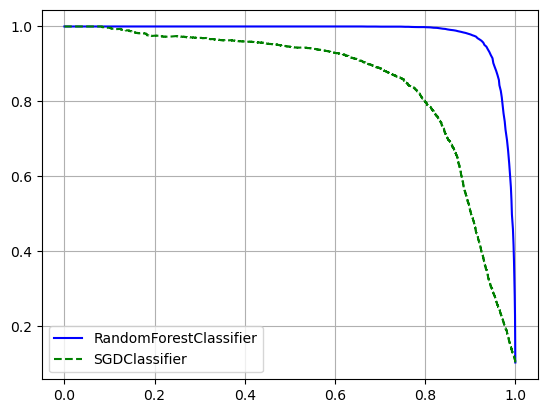

In [187]:
plt.plot(rRF, pRF, "b-", label = "RandomForestClassifier")
plt.plot(recall, precision, "g--", label="SGDClassifier")
plt.grid(True)
plt.legend()
plt.show()

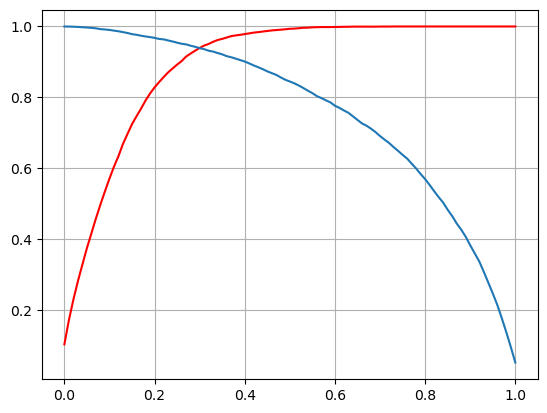

In [188]:
plt.plot(tRF, pRF[:-1], 'r-')
plt.plot(tRF, rRF[:-1])
plt.grid()
plt.show()

In [189]:
indexOf9r = (rRF <= 0.9).argmax()
thresholdOf90Recall = tRF[indexOf9r]
thresholdOf90Recall

np.float64(0.41)

In [190]:
yThree = (predictProbaScore[:,1] >= thresholdOf90Recall)
str(round(((recall_score(yTr, yThree))*100), 0))+"%"

'90.0%'

In [191]:
str(round(((precision_score(yTr, yThree))*100), 1))+"%"

'98.1%'

In [192]:
str(round(((f1_score(yTr, yThree))*100), 1))+"%"

'93.6%'

In [193]:
str(round(((roc_auc_score(yTr, yThree))*100), 1))+"%"

'94.7%'

In [194]:
rFCModel.fit(xTrain, yTr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


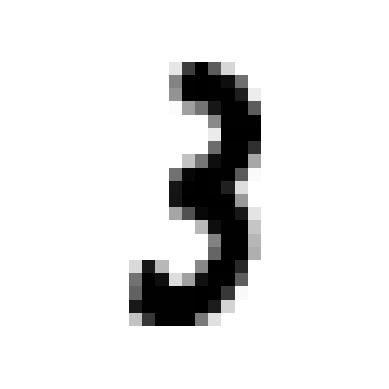

Is this a image of 3?
AI: True


In [246]:
randomIndex = np.random.randint(low=0, high=60000, dtype=int)
displayImage(xTrain[randomIndex, :])
print("Is this a image of 3?")
print(f"AI: {((rFCModel.predict_proba([xTrain[randomIndex, :]])[:,1]>=thresholdOf90Recall)[0])}")